In [1]:
!pip install numpy pandas matplotlib scipy


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Load all NCU data

In [2]:
import pandas as pd

metrics_df_raw: pd.DataFrame = pd.read_csv('metrics/metrics_all_ncu.csv')
metrics_df_raw

,GpuName,SeqLen,HeadDim,Run,Range,Action,dram__cycles_active.avg,gpu__time_duration.sum,l1tex__cycles_active.avg,lts__cycles_active.avg,...,smsp__pcsamp_warps_issue_stalled_short_scoreboard,smsp__warps_issue_stalled_long_scoreboard.avg,smsp__warps_issue_stalled_math_pipe_throttle.avg,smsp__warps_issue_stalled_mio_throttle.avg,smsp__warps_issue_stalled_not_selected.avg,smsp__warps_issue_stalled_short_scoreboard.avg,smsp__warps_issue_stalled_wait.avg,sm__pipe_aluheavy_cycles_active.avg,sm__pipe_fmaheavy_cycles_active.avg,sm__pipe_fmalite_cycles_active.avg
0,a100-sxm4-40gb,256,64,0,0,unrolled_elementwise_kernel,50.7,7456.0,1.601593e+03,1.757700e+03,...,1.0,6.297593e+02,0.000000e+00,0.00000,0.000000e+00,29.888889,2.408889e+02,NaN,NaN,NaN
1,a100-sxm4-40gb,256,64,0,0,unrolled_elementwise_kernel,50.7,7424.0,1.583741e+03,1.842463e+03,...,1.0,6.119074e+02,0.000000e+00,0.00000,0.000000e+00,29.824074,2.408889e+02,NaN,NaN,NaN
2,a100-sxm4-40gb,256,64,0,0,unrolled_elementwise_kernel,50.7,7392.0,1.582528e+03,1.733312e+03,...,3.0,6.324398e+02,0.000000e+00,0.00000,0.000000e+00,29.761574,2.408889e+02,NaN,NaN,NaN
3,a100-sxm4-40gb,256,64,0,0,vectorized_elementwise_kernel,54.9,3616.0,2.510556e+02,9.283125e+02,...,0.0,1.009421e+02,0.000000e+00,0.00000,0.000000e+00,1.629630,1.111111e+01,NaN,NaN,NaN
4,a100-sxm4-40gb,256,64,0,0,vectorized_elementwise_kernel,54.9,3616.0,2.438796e+02,1.060450e+03,...,0.0,9.570602e+01,0.000000e+00,0.00000,0.000000e+00,1.629630,1.111111e+01,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2566,t4,8192,128,2,0,volta_sgemm_128x64_nn,9625981.5,5933664.0,3.467783e+06,5.058044e+06,...,544.0,7.826174e+04,3.940338e+06,338280.45625,3.955725e+06,51981.656250,1.556349e+06,NaN,NaN,NaN
2567,t4,8192,128,2,0,vectorized_elementwise_kernel,92463.0,24160.0,1.223858e+04,1.769500e+04,...,6.0,5.292419e+04,1.435188e+02,210.20625,2.052250e+02,1051.981250,3.356756e+03,NaN,NaN,NaN
2568,t4,8192,128,0,0,fmha_cutlassF_f16_aligned_32x128_rf_sm75,411159.0,5579392.0,2.897558e+06,3.540478e+06,...,18328.0,1.083766e+06,1.906061e+05,389439.61250,1.069107e+05,915427.650000,1.209729e+06,NaN,NaN,NaN
2569,t4,8192,128,1,0,fmha_cutlassF_f16_aligned_32x128_rf_sm75,412807.0,5591008.0,2.903576e+06,3.496220e+06,...,18373.0,1.072384e+06,1.908920e+05,391341.08125,1.065178e+05,917177.125000,1.210074e+06,NaN,NaN,NaN


In [3]:
# convert stall cols to proportions instead of raw sample counts
stall_cols = [c for c in metrics_df_raw.columns if c.startswith('smsp__pcsamp_warps_issue_stalled_')]
metrics_df = metrics_df_raw.copy()
total_samples = metrics_df_raw[stall_cols].sum(axis=1)
metrics_df[stall_cols] = metrics_df_raw[stall_cols].div(total_samples, axis=0)
metrics_df

,GpuName,SeqLen,HeadDim,Run,Range,Action,dram__cycles_active.avg,gpu__time_duration.sum,l1tex__cycles_active.avg,lts__cycles_active.avg,...,smsp__pcsamp_warps_issue_stalled_short_scoreboard,smsp__warps_issue_stalled_long_scoreboard.avg,smsp__warps_issue_stalled_math_pipe_throttle.avg,smsp__warps_issue_stalled_mio_throttle.avg,smsp__warps_issue_stalled_not_selected.avg,smsp__warps_issue_stalled_short_scoreboard.avg,smsp__warps_issue_stalled_wait.avg,sm__pipe_aluheavy_cycles_active.avg,sm__pipe_fmaheavy_cycles_active.avg,sm__pipe_fmalite_cycles_active.avg
0,a100-sxm4-40gb,256,64,0,0,unrolled_elementwise_kernel,50.7,7456.0,1.601593e+03,1.757700e+03,...,0.020833,6.297593e+02,0.000000e+00,0.00000,0.000000e+00,29.888889,2.408889e+02,NaN,NaN,NaN
1,a100-sxm4-40gb,256,64,0,0,unrolled_elementwise_kernel,50.7,7424.0,1.583741e+03,1.842463e+03,...,0.025000,6.119074e+02,0.000000e+00,0.00000,0.000000e+00,29.824074,2.408889e+02,NaN,NaN,NaN
2,a100-sxm4-40gb,256,64,0,0,unrolled_elementwise_kernel,50.7,7392.0,1.582528e+03,1.733312e+03,...,0.096774,6.324398e+02,0.000000e+00,0.00000,0.000000e+00,29.761574,2.408889e+02,NaN,NaN,NaN
3,a100-sxm4-40gb,256,64,0,0,vectorized_elementwise_kernel,54.9,3616.0,2.510556e+02,9.283125e+02,...,NaN,1.009421e+02,0.000000e+00,0.00000,0.000000e+00,1.629630,1.111111e+01,NaN,NaN,NaN
4,a100-sxm4-40gb,256,64,0,0,vectorized_elementwise_kernel,54.9,3616.0,2.438796e+02,1.060450e+03,...,0.000000,9.570602e+01,0.000000e+00,0.00000,0.000000e+00,1.629630,1.111111e+01,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2566,t4,8192,128,2,0,volta_sgemm_128x64_nn,9625981.5,5933664.0,3.467783e+06,5.058044e+06,...,0.006699,7.826174e+04,3.940338e+06,338280.45625,3.955725e+06,51981.656250,1.556349e+06,NaN,NaN,NaN
2567,t4,8192,128,2,0,vectorized_elementwise_kernel,92463.0,24160.0,1.223858e+04,1.769500e+04,...,0.017391,5.292419e+04,1.435188e+02,210.20625,2.052250e+02,1051.981250,3.356756e+03,NaN,NaN,NaN
2568,t4,8192,128,0,0,fmha_cutlassF_f16_aligned_32x128_rf_sm75,411159.0,5579392.0,2.897558e+06,3.540478e+06,...,0.392446,1.083766e+06,1.906061e+05,389439.61250,1.069107e+05,915427.650000,1.209729e+06,NaN,NaN,NaN
2569,t4,8192,128,1,0,fmha_cutlassF_f16_aligned_32x128_rf_sm75,412807.0,5591008.0,2.903576e+06,3.496220e+06,...,0.392619,1.072384e+06,1.908920e+05,391341.08125,1.065178e+05,917177.125000,1.210074e+06,NaN,NaN,NaN


In [4]:
metrics_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2571 entries, 0 to 2570
Data columns (total 45 columns):
 #   Column                                                         Non-Null Count  Dtype  
---  ------                                                         --------------  -----  
 0   GpuName                                                        2571 non-null   str    
 1   SeqLen                                                         2571 non-null   int64  
 2   HeadDim                                                        2571 non-null   int64  
 3   Run                                                            2571 non-null   int64  
 4   Range                                                          2571 non-null   int64  
 5   Action                                                         2571 non-null   str    
 6   dram__cycles_active.avg                                        2571 non-null   float64
 7   gpu__time_duration.sum                                         2571 non

In [5]:
LABEL_COLS = ['GpuName', 'SeqLen', 'HeadDim', 'Run', 'Action', 'Range']

## Compare runs for sanity check

In [6]:
metrics_df_run0 = metrics_df[metrics_df['Run'] == 0].reset_index(drop=True)
metrics_df_run1 = metrics_df[metrics_df['Run'] == 1].reset_index(drop=True)
metrics_df_run2 = metrics_df[metrics_df['Run'] == 2].reset_index(drop=True)
metrics_df_run0

,GpuName,SeqLen,HeadDim,Run,Range,Action,dram__cycles_active.avg,gpu__time_duration.sum,l1tex__cycles_active.avg,lts__cycles_active.avg,...,smsp__pcsamp_warps_issue_stalled_short_scoreboard,smsp__warps_issue_stalled_long_scoreboard.avg,smsp__warps_issue_stalled_math_pipe_throttle.avg,smsp__warps_issue_stalled_mio_throttle.avg,smsp__warps_issue_stalled_not_selected.avg,smsp__warps_issue_stalled_short_scoreboard.avg,smsp__warps_issue_stalled_wait.avg,sm__pipe_aluheavy_cycles_active.avg,sm__pipe_fmaheavy_cycles_active.avg,sm__pipe_fmalite_cycles_active.avg
0,a100-sxm4-40gb,256,64,0,0,unrolled_elementwise_kernel,50.7,7456.0,1.601593e+03,1.757700e+03,...,0.020833,6.297593e+02,0.000000e+00,0.00000,0.000000e+00,29.888889,2.408889e+02,NaN,NaN,NaN
1,a100-sxm4-40gb,256,64,0,0,unrolled_elementwise_kernel,50.7,7424.0,1.583741e+03,1.842463e+03,...,0.025000,6.119074e+02,0.000000e+00,0.00000,0.000000e+00,29.824074,2.408889e+02,NaN,NaN,NaN
2,a100-sxm4-40gb,256,64,0,0,unrolled_elementwise_kernel,50.7,7392.0,1.582528e+03,1.733312e+03,...,0.096774,6.324398e+02,0.000000e+00,0.00000,0.000000e+00,29.761574,2.408889e+02,NaN,NaN,NaN
3,a100-sxm4-40gb,256,64,0,0,vectorized_elementwise_kernel,54.9,3616.0,2.510556e+02,9.283125e+02,...,NaN,1.009421e+02,0.000000e+00,0.00000,0.000000e+00,1.629630,1.111111e+01,NaN,NaN,NaN
4,a100-sxm4-40gb,256,64,0,0,vectorized_elementwise_kernel,54.9,3616.0,2.438796e+02,1.060450e+03,...,0.000000,9.570602e+01,0.000000e+00,0.00000,0.000000e+00,1.629630,1.111111e+01,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,t4,8192,128,0,0,elementwise_kernel,9641152.5,2317536.0,1.354124e+06,1.977462e+06,...,0.019228,6.349017e+06,2.223474e+05,739.10000,3.436425e+05,148696.475000,1.318682e+06,NaN,NaN,NaN
853,t4,8192,128,0,0,vectorized_elementwise_kernel,6942755.0,1568448.0,9.150590e+05,1.331819e+06,...,0.017845,6.207038e+06,1.491325e+03,36598.96875,9.233056e+03,106809.768750,2.115388e+05,NaN,NaN,NaN
854,t4,8192,128,0,0,volta_sgemm_128x64_nn,9625974.0,5933856.0,3.467528e+06,5.056996e+06,...,0.007023,7.836398e+04,3.942865e+06,339112.88125,3.958883e+06,51682.506250,1.556348e+06,NaN,NaN,NaN
855,t4,8192,128,0,0,vectorized_elementwise_kernel,92942.0,24640.0,1.231095e+04,1.778759e+04,...,0.014245,5.335439e+04,1.445000e+02,202.98750,2.091875e+02,1055.325000,3.356800e+03,NaN,NaN,NaN


In [7]:
import numpy as np
from scipy.stats import variation

data_cols = [c for c in metrics_df_run0.columns if c not in LABEL_COLS]

# Stack runs along axis 0 → shape (3, n_rows, n_data_cols)
stacked = np.stack([
    metrics_df_run0[data_cols].values,
    metrics_df_run1[data_cols].values,
    metrics_df_run2[data_cols].values
], axis=0)

# CV = std/mean across the 3 runs for each (row, metric) pair
diff_df = metrics_df_run0[LABEL_COLS].copy()
diff_df[data_cols] = variation(stacked, axis=0)

diff_df

,GpuName,SeqLen,HeadDim,Run,Action,Range,dram__cycles_active.avg,gpu__time_duration.sum,l1tex__cycles_active.avg,lts__cycles_active.avg,...,smsp__pcsamp_warps_issue_stalled_short_scoreboard,smsp__warps_issue_stalled_long_scoreboard.avg,smsp__warps_issue_stalled_math_pipe_throttle.avg,smsp__warps_issue_stalled_mio_throttle.avg,smsp__warps_issue_stalled_not_selected.avg,smsp__warps_issue_stalled_short_scoreboard.avg,smsp__warps_issue_stalled_wait.avg,sm__pipe_aluheavy_cycles_active.avg,sm__pipe_fmaheavy_cycles_active.avg,sm__pipe_fmalite_cycles_active.avg
0,a100-sxm4-40gb,256,64,0,unrolled_elementwise_kernel,0,1.401465e-16,0.013363,0.016247,0.017873,...,0.891731,0.005261,NaN,NaN,NaN,0.000774,0.000000e+00,NaN,NaN,NaN
1,a100-sxm4-40gb,256,64,0,unrolled_elementwise_kernel,0,1.401465e-16,0.008175,0.002018,0.013518,...,0.868519,0.012819,NaN,NaN,NaN,0.000253,0.000000e+00,NaN,NaN,NaN
2,a100-sxm4-40gb,256,64,0,unrolled_elementwise_kernel,0,1.401465e-16,0.010957,0.006833,0.008030,...,0.820874,0.007411,NaN,NaN,NaN,0.001463,0.000000e+00,NaN,NaN,NaN
3,a100-sxm4-40gb,256,64,0,vectorized_elementwise_kernel,0,0.000000e+00,0.004184,0.001615,0.006719,...,NaN,0.032590,NaN,NaN,NaN,0.000000,1.598721e-16,NaN,NaN,NaN
4,a100-sxm4-40gb,256,64,0,vectorized_elementwise_kernel,0,0.000000e+00,0.000000,0.002144,0.004748,...,NaN,0.049561,NaN,NaN,NaN,0.000000,1.598721e-16,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,t4,8192,128,0,elementwise_kernel,0,3.544249e-05,0.000265,0.000274,0.000268,...,0.018765,0.000340,0.002920,0.026399,0.001377,0.000509,3.749351e-05,NaN,NaN,NaN
853,t4,8192,128,0,vectorized_elementwise_kernel,0,2.845461e-04,0.000451,0.000507,0.000492,...,0.047431,0.002274,0.001035,0.004009,0.004761,0.004666,9.732628e-05,NaN,NaN,NaN
854,t4,8192,128,0,volta_sgemm_128x64_nn,0,1.167204e-05,0.000140,0.000036,0.000117,...,0.031511,0.000625,0.000304,0.003046,0.000348,0.002941,2.091027e-06,NaN,NaN,NaN
855,t4,8192,128,0,vectorized_elementwise_kernel,0,2.977597e-03,0.008035,0.002820,0.002628,...,0.193206,0.004602,0.005474,0.016373,0.012894,0.002427,9.486217e-04,NaN,NaN,NaN


In [8]:
threshold = 0.03
data_cols = [c for c in diff_df.columns if c not in LABEL_COLS]

flagged = (
    diff_df[data_cols]
    .stack()
    .reset_index()
    .rename(columns={'level_1': 'metric', 0: 'cv'})
    .query('cv >= @threshold')
)

label_vals = diff_df.loc[flagged['level_0'], LABEL_COLS].reset_index(drop=True)
flagged_df = pd.concat([label_vals, flagged[['metric', 'cv']].reset_index(drop=True)], axis=1)
flagged_df

,GpuName,SeqLen,HeadDim,Run,Action,Range,metric,cv
0,a100-sxm4-40gb,256,64,0,unrolled_elementwise_kernel,0,smsp__pcsamp_warps_issue_stalled_short_scoreboard,0.891731
1,a100-sxm4-40gb,256,64,0,unrolled_elementwise_kernel,0,smsp__pcsamp_warps_issue_stalled_short_scoreboard,0.868519
2,a100-sxm4-40gb,256,64,0,unrolled_elementwise_kernel,0,smsp__pcsamp_warps_issue_stalled_long_scoreboard,0.041507
3,a100-sxm4-40gb,256,64,0,unrolled_elementwise_kernel,0,smsp__pcsamp_warps_issue_stalled_short_scoreboard,0.820874
4,a100-sxm4-40gb,256,64,0,vectorized_elementwise_kernel,0,smsp__warps_issue_stalled_long_scoreboard.avg,0.032590
...,...,...,...,...,...,...,...,...
2864,t4,8192,128,0,volta_sgemm_128x64_nn,0,smsp__pcsamp_warps_issue_stalled_lg_throttle,0.108126
2865,t4,8192,128,0,volta_sgemm_128x64_nn,0,smsp__pcsamp_warps_issue_stalled_membar,0.228092
2866,t4,8192,128,0,volta_sgemm_128x64_nn,0,smsp__pcsamp_warps_issue_stalled_short_scoreboard,0.031511
2867,t4,8192,128,0,vectorized_elementwise_kernel,0,smsp__pcsamp_warps_issue_stalled_short_scoreboard,0.193206


## Get Utilization Percentages

In [9]:
sm_cycles_elapsed = metrics_df_run0['sm__cycles_elapsed.avg']

util_df = metrics_df_run0[LABEL_COLS]
util_df['SM_Util'] = metrics_df_run0['sm__cycles_active.avg'] / sm_cycles_elapsed
util_df['Tensor_Util'] = metrics_df_run0['sm__pipe_tensor_cycles_active.avg'] / sm_cycles_elapsed
util_df['FMA_Util'] = metrics_df_run0['sm__pipe_fma_cycles_active.avg'] / sm_cycles_elapsed
util_df['FMA_Heavy_Util'] = metrics_df_run0['sm__pipe_fmaheavy_cycles_active.avg'] / sm_cycles_elapsed
util_df['FMA_Lite_Util'] = metrics_df_run0['sm__pipe_fmalite_cycles_active.avg'] / sm_cycles_elapsed
util_df['Shared_Util'] = metrics_df_run0['sm__pipe_shared_cycles_active.avg'] / sm_cycles_elapsed
util_df['ALU_Util'] = metrics_df_run0['sm__pipe_alu_cycles_active.avg'] / sm_cycles_elapsed
util_df['ALU_Heavy_Util'] = metrics_df_run0['sm__pipe_aluheavy_cycles_active.avg'] / sm_cycles_elapsed
# util_df['ALU_Lite_Util'] = metrics_df_run0['sm__pipe_alulite_cycles_active.avg'] / sm_cycles_elapsed
# util_df['FP16_Util'] = metrics_df_run0['sm__pipe_fp16_cycles_active.avg'] / sm_cycles_elapsed
util_df['FP64_Util'] = metrics_df_run0['sm__pipe_fp64_cycles_active.avg'] / sm_cycles_elapsed
util_df['L1_Cache_Util'] = metrics_df_run0['l1tex__cycles_active.avg'] / sm_cycles_elapsed
# util_df['L1_Cache_Util_Ampere+'] = metrics_df_run0['1tex__cycles_active.avg'] / sm_cycles_elapsed
util_df['LTS_Util'] = metrics_df_run0['lts__cycles_active.avg'] / sm_cycles_elapsed
util_df['DRAM_Util'] = metrics_df_run0['dram__cycles_active.avg'] / sm_cycles_elapsed

# Normalize from pct-of-peak (0–100) to fraction (0–1) to match other units
util_df['SFU_Util'] = metrics_df_run0['smsp__inst_executed_pipe_xu.avg.pct_of_peak_sustained_elapsed'] / 100.0
util_df['SMSP_Util'] = metrics_df_run0['smsp__issue_active.avg.pct_of_peak_sustained_elapsed'] / 100.0

util_df

,GpuName,SeqLen,HeadDim,Run,Action,Range,SM_Util,Tensor_Util,FMA_Util,FMA_Heavy_Util,FMA_Lite_Util,Shared_Util,ALU_Util,ALU_Heavy_Util,FP64_Util,L1_Cache_Util,LTS_Util,DRAM_Util,SFU_Util,SMSP_Util
0,a100-sxm4-40gb,256,64,0,unrolled_elementwise_kernel,0,0.197860,0.000000,0.010542,NaN,NaN,0.000000,0.019327,NaN,0.000000,0.197860,0.217145,0.006263,0.000000,0.007357
1,a100-sxm4-40gb,256,64,0,unrolled_elementwise_kernel,0,0.196005,0.000000,0.010561,NaN,NaN,0.000000,0.019362,NaN,0.000000,0.196005,0.228025,0.006275,0.000000,0.007371
2,a100-sxm4-40gb,256,64,0,unrolled_elementwise_kernel,0,0.197519,0.000000,0.010651,NaN,NaN,0.000000,0.019526,NaN,0.000000,0.197519,0.216339,0.006328,0.000000,0.007433
3,a100-sxm4-40gb,256,64,0,vectorized_elementwise_kernel,0,0.064764,0.000306,0.003975,NaN,NaN,0.000306,0.000917,NaN,0.000000,0.064764,0.239475,0.014162,0.000000,0.001223
4,a100-sxm4-40gb,256,64,0,vectorized_elementwise_kernel,0,0.062554,0.000304,0.003952,NaN,NaN,0.000304,0.000912,NaN,0.000000,0.062554,0.271999,0.014082,0.000000,0.001216
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
852,t4,8192,128,0,elementwise_kernel,0,0.998809,0.000000,0.928122,NaN,NaN,0.000000,1.198824,NaN,0.000000,0.998809,1.458585,7.111361,0.000000,0.420615
853,t4,8192,128,0,vectorized_elementwise_kernel,0,0.997319,0.000000,0.114284,NaN,NaN,0.000000,0.085713,NaN,0.000000,0.997319,1.451545,7.566882,0.114284,0.053593
854,t4,8192,128,0,volta_sgemm_128x64_nn,0,0.998914,0.000000,3.875075,NaN,NaN,0.000000,0.188403,NaN,0.000000,0.998914,1.456802,2.773018,0.000000,0.564524
855,t4,8192,128,0,vectorized_elementwise_kernel,0,0.855973,0.000000,0.113917,NaN,NaN,0.000000,0.085438,NaN,0.000000,0.855973,1.236761,6.462204,0.113917,0.054827


In [10]:
util_df.to_csv('metrics/util_ncu.csv')

## Plot Utilization

In [11]:
GPU_LABELS = {
    'rtx2060': 'RTX 2060',
    't4': 'T4',
    'a100-sxm4-40gb': 'A100',
    'l4': 'L4',
    'h10080gbhbm3': 'H100',
    'rtxpro6000blackwellserveredition': 'Blackwell',
}
GPU_ORDER = ['RTX 2060', 'T4', 'A100', 'L4', 'H100', 'Blackwell']

### Math (Eager/Non-fused) Backend

In [12]:
exclude_prefixes = ('fmha_cutlassF_', 'flash_fwd_', 'cudnn_')
metrics_df_run0_math_only = metrics_df_run0[~metrics_df_run0['Action'].str.startswith(exclude_prefixes)].reset_index()
metrics_df_run0_math_only.head(46)

,index,GpuName,SeqLen,HeadDim,Run,Range,Action,dram__cycles_active.avg,gpu__time_duration.sum,l1tex__cycles_active.avg,...,smsp__pcsamp_warps_issue_stalled_short_scoreboard,smsp__warps_issue_stalled_long_scoreboard.avg,smsp__warps_issue_stalled_math_pipe_throttle.avg,smsp__warps_issue_stalled_mio_throttle.avg,smsp__warps_issue_stalled_not_selected.avg,smsp__warps_issue_stalled_short_scoreboard.avg,smsp__warps_issue_stalled_wait.avg,sm__pipe_aluheavy_cycles_active.avg,sm__pipe_fmaheavy_cycles_active.avg,sm__pipe_fmalite_cycles_active.avg
0,0,a100-sxm4-40gb,256,64,0,0,unrolled_elementwise_kernel,50.7,7456.0,1601.592593,...,0.020833,629.759259,0.000000,0.000000,0.000000,29.888889,240.888889,NaN,NaN,NaN
1,1,a100-sxm4-40gb,256,64,0,0,unrolled_elementwise_kernel,50.7,7424.0,1583.740741,...,0.025000,611.907407,0.000000,0.000000,0.000000,29.824074,240.888889,NaN,NaN,NaN
2,2,a100-sxm4-40gb,256,64,0,0,unrolled_elementwise_kernel,50.7,7392.0,1582.527778,...,0.096774,632.439815,0.000000,0.000000,0.000000,29.761574,240.888889,NaN,NaN,NaN
3,3,a100-sxm4-40gb,256,64,0,0,vectorized_elementwise_kernel,54.9,3616.0,251.055556,...,NaN,100.942130,0.000000,0.000000,0.000000,1.629630,11.111111,NaN,NaN,NaN
4,4,a100-sxm4-40gb,256,64,0,0,vectorized_elementwise_kernel,54.9,3616.0,243.879630,...,0.000000,95.706019,0.000000,0.000000,0.000000,1.629630,11.111111,NaN,NaN,NaN
5,5,a100-sxm4-40gb,256,64,0,0,ampere_sgemm_32x32_sliced1x4_tn,115.2,8768.0,4252.379630,...,0.058824,655.363426,1.777778,98.685185,0.000000,150.349537,1210.032407,NaN,NaN,NaN
6,6,a100-sxm4-40gb,256,64,0,0,softmax_warp_forward,212.3,5024.0,1827.851852,...,0.456522,343.949074,0.000000,0.000000,0.000000,251.854167,401.777778,NaN,NaN,NaN
7,7,a100-sxm4-40gb,256,64,0,0,vectorized_elementwise_kernel,208.9,3744.0,1007.925926,...,0.000000,367.655093,0.000000,0.000000,0.000000,8.888889,45.037037,NaN,NaN,NaN
8,8,a100-sxm4-40gb,256,64,0,0,reduce_kernel,93.4,7680.0,878.314815,...,0.125000,615.439815,106.946759,1.192130,125.738426,111.111111,362.710648,NaN,NaN,NaN
9,9,a100-sxm4-40gb,256,64,0,0,vectorized_elementwise_kernel,3.1,3008.0,13.111111,...,NaN,0.000000,0.000000,0.000000,0.000000,0.129630,1.074074,NaN,NaN,NaN


#### Duration of each Kernel type

In [13]:
import os
import matplotlib.pyplot as plt


def plot_math_kernel_durations(gpu_name: str, seq_len: int, head_dim: int,
                               show: bool = False, save: bool = False):
    """Bar chart of total sm__cycles_elapsed.avg per Math-backend kernel name
    for a single (gpu_name, seq_len, head_dim) config.

    Excludes fmha_cutlassF_ (xformers/MEA), flash_fwd_ (FA2), and cudnn_ kernels.
    Multiple invocations of the same kernel name are summed.
    """
    reverse_gpu_labels = {v: k for k, v in GPU_LABELS.items()}
    raw_gpu_name = reverse_gpu_labels[gpu_name]

    sub = metrics_df_run0_math_only[
        (metrics_df_run0_math_only['GpuName'] == raw_gpu_name) &
        (metrics_df_run0_math_only['SeqLen'] == seq_len) &
        (metrics_df_run0_math_only['HeadDim'] == head_dim)
        ].copy()

    assert not sub.empty, (
        f"No Math kernel data for gpu_name='{gpu_name}', seq_len={seq_len}, head_dim={head_dim}"
    )

    agg = (sub.groupby('Action')['sm__cycles_elapsed.avg']
           .sum()
           .sort_values(ascending=False))

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(range(len(agg)), agg.values)
    ax.set_xticks(range(len(agg)))
    ax.set_xticklabels(agg.index, rotation=45, ha='right', fontsize=8)
    ax.set_title(f'Math Kernel Durations — {gpu_name}, SeqLen={seq_len}, HeadDim={head_dim}')
    ax.set_xlabel('Kernel')
    ax.set_ylabel('Total sm__cycles_elapsed.avg (cycles)')
    fig.tight_layout()

    if save:
        os.makedirs('plots/math_kernel_durations', exist_ok=True)
        plt.savefig(f'plots/math_kernel_durations/{gpu_name}_{seq_len}x{head_dim}.png')

    if show:
        plt.show()
    else:
        plt.close()

Note that `volta_sgemm_*`, `ampere_sgemm_*`, `sm80_xmma_gemm_`, and `Kernel2` kernels are all Matrix Mult

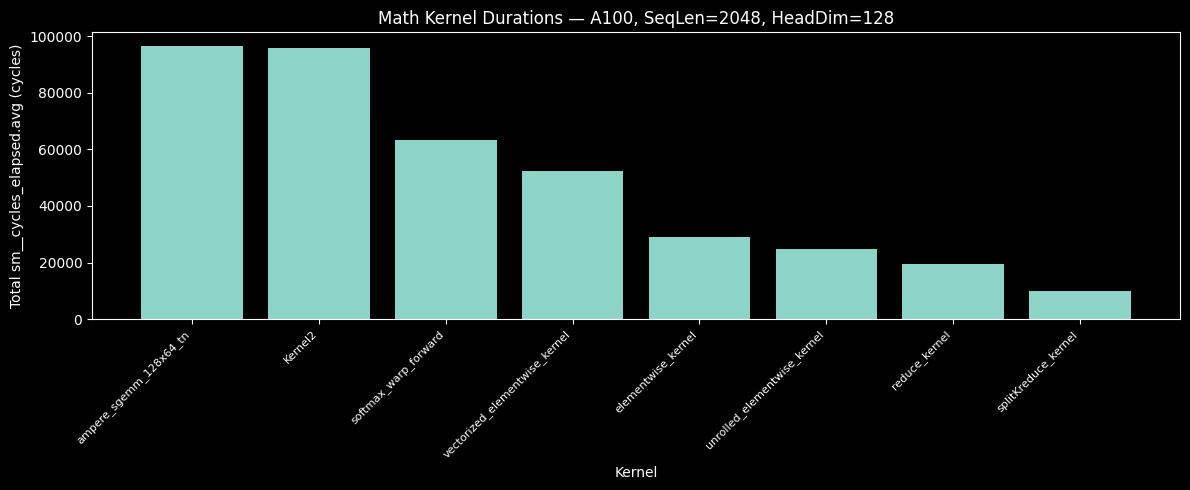

In [14]:
# Example
plot_math_kernel_durations('A100', 2048, 128, show=True)

In [15]:
for gpu_name in GPU_ORDER:
    for seq_len in metrics_df_run0['SeqLen'].unique():
        for head_dim in metrics_df_run0['HeadDim'].unique():
            try:
                plot_math_kernel_durations(gpu_name, seq_len, head_dim, save=True)
            except Exception as e:
                print(e)

No Math kernel data for gpu_name='RTX 2060', seq_len=256, head_dim=64
No Math kernel data for gpu_name='RTX 2060', seq_len=256, head_dim=128
No Math kernel data for gpu_name='RTX 2060', seq_len=512, head_dim=64
No Math kernel data for gpu_name='RTX 2060', seq_len=512, head_dim=128
No Math kernel data for gpu_name='RTX 2060', seq_len=1024, head_dim=64
No Math kernel data for gpu_name='RTX 2060', seq_len=1024, head_dim=128
No Math kernel data for gpu_name='RTX 2060', seq_len=2048, head_dim=64
No Math kernel data for gpu_name='RTX 2060', seq_len=2048, head_dim=128
No Math kernel data for gpu_name='RTX 2060', seq_len=4096, head_dim=64
No Math kernel data for gpu_name='RTX 2060', seq_len=4096, head_dim=128
No Math kernel data for gpu_name='RTX 2060', seq_len=8192, head_dim=64
No Math kernel data for gpu_name='RTX 2060', seq_len=8192, head_dim=128


/var/folders/zp/rr203r4x1vj22lh9pzzc37z80000gn/T/ipykernel_16527/2561469066.py:37: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()
/var/folders/zp/rr203r4x1vj22lh9pzzc37z80000gn/T/ipykernel_16527/2561469066.py:37: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()
/var/folders/zp/rr203r4x1vj22lh9pzzc37z80000gn/T/ipykernel_16527/2561469066.py:37: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()
/var/folders/zp/rr203r4x1vj22lh9pzzc37z80000gn/T/ipykernel_16527/2561469066.py:37: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()
/var/folders/zp/rr203r4x1vj22lh9pzzc37z80000gn/T/ipykernel_1

#### Functional Unit Utilization

In [16]:
MATH_UTIL_COLS = {
    'SM_Util':        'sm__cycles_active.avg',
    'Tensor_Util':    'sm__pipe_tensor_cycles_active.avg',
    'FMA_Util':       'sm__pipe_fma_cycles_active.avg',
    'FMA_Heavy_Util': 'sm__pipe_fmaheavy_cycles_active.avg',
    'FMA_Lite_Util':  'sm__pipe_fmalite_cycles_active.avg',
    'Shared_Util':    'sm__pipe_shared_cycles_active.avg',
    'ALU_Util':       'sm__pipe_alu_cycles_active.avg',
    'ALU_Heavy_Util': 'sm__pipe_aluheavy_cycles_active.avg',
    'FP64_Util':      'sm__pipe_fp64_cycles_active.avg',
    'L1_Cache_Util':  'l1tex__cycles_active.avg',
    'LTS_Util':       'lts__cycles_active.avg',
    'DRAM_Util':      'dram__cycles_active.avg',
}

# Percent-of-peak metrics require weighted-average aggregation:
#   weighted_util = sum((U_i / 100) * elapsed_i) / sum(elapsed_i)
MATH_PCT_COLS = {
    'SFU_Util':  'smsp__inst_executed_pipe_xu.avg.pct_of_peak_sustained_elapsed',
    'SMSP_Util': 'smsp__issue_active.avg.pct_of_peak_sustained_elapsed',
}

GROUP_COLS = ['GpuName', 'SeqLen', 'HeadDim']

# Pre-compute weighted products for pct-of-peak metrics before groupby
math_df = metrics_df_run0_math_only.copy()
for util_name, raw_col in MATH_PCT_COLS.items():
    math_df[f'_weighted_{util_name}'] = math_df[raw_col] * math_df['sm__cycles_elapsed.avg']

weighted_cols = [f'_weighted_{k}' for k in MATH_PCT_COLS]
agg_cols = list(MATH_UTIL_COLS.values()) + ['sm__cycles_elapsed.avg'] + weighted_cols

math_agg = (
    math_df[GROUP_COLS + agg_cols]
    .groupby(GROUP_COLS)
    .sum()
    .reset_index()
)

util_df_math_only = math_agg[GROUP_COLS].copy()
for util_col, raw_col in MATH_UTIL_COLS.items():
    util_df_math_only[util_col] = math_agg[raw_col] / math_agg['sm__cycles_elapsed.avg']

for util_name in MATH_PCT_COLS:
    util_df_math_only[util_name] = (
        math_agg[f'_weighted_{util_name}'] / math_agg['sm__cycles_elapsed.avg'] / 100
    )

util_df_math_only

,GpuName,SeqLen,HeadDim,SM_Util,Tensor_Util,FMA_Util,FMA_Heavy_Util,FMA_Lite_Util,Shared_Util,ALU_Util,ALU_Heavy_Util,FP64_Util,L1_Cache_Util,LTS_Util,DRAM_Util,SFU_Util,SMSP_Util
0,a100-sxm4-40gb,256,64,0.253211,0.001166,0.079752,0.000000,0.000000,0.001166,0.080092,0.000000,0.0,0.253211,0.281641,0.020259,0.001244,0.028551
1,a100-sxm4-40gb,256,128,0.341352,0.001281,0.133492,0.000000,0.000000,0.001281,0.100543,0.000000,0.0,0.341352,0.304583,0.023363,0.001141,0.040627
2,a100-sxm4-40gb,512,64,0.397244,0.003240,0.244778,0.000000,0.000000,0.003240,0.184797,0.000000,0.0,0.397244,0.361158,0.052039,0.004035,0.073678
3,a100-sxm4-40gb,512,128,0.532075,0.003247,0.396887,0.000000,0.000000,0.003247,0.245301,0.000000,0.0,0.532075,0.481518,0.063922,0.003800,0.108155
4,a100-sxm4-40gb,1024,64,0.580068,0.007327,0.638845,0.000000,0.000000,0.007327,0.392419,0.000000,0.0,0.580068,0.524601,0.123217,0.011251,0.171136
5,a100-sxm4-40gb,1024,128,0.624238,0.006654,0.912342,0.000000,0.000000,0.006654,0.382022,0.000000,0.0,0.624238,0.606374,0.114278,0.009255,0.208955
6,a100-sxm4-40gb,2048,64,0.737999,0.013631,1.268954,0.000000,0.000000,0.013631,0.562952,0.000000,0.0,0.737999,0.672373,0.252142,0.023658,0.292731
7,a100-sxm4-40gb,2048,128,0.786090,0.011355,1.797953,0.000000,0.000000,0.011355,0.583252,0.000000,0.0,0.786090,0.731612,0.212568,0.018626,0.365274
8,a100-sxm4-40gb,4096,64,0.955198,0.037385,1.963722,0.000000,0.000000,0.037385,0.840562,0.000000,0.0,0.955198,0.924210,0.557342,0.000000,0.444188
9,a100-sxm4-40gb,4096,128,0.968765,0.025756,2.437556,0.000000,0.000000,0.025756,0.784873,0.000000,0.0,0.968765,0.936143,0.396423,0.000000,0.499481


The following sections exclude the Math backend.

### Setup

In [17]:
KERNEL_ORDER = ['xformers', 'FA2', 'cuDNN']


def label_kernel(name: str):
    """
    Currently excludes Math kernels
    """
    if 'flash_fwd_splitkv_combine' in name: return None  # exclude reduction step
    if 'flash_fwd' in name: return 'FA2'  # covers flash_fwd_kernel and split_kv
    if 'cudnn_generated' in name: return 'cuDNN'
    if 'fmha_cutlassF' in name: return 'xformers'
    return None

In [18]:
UNIT_COLS = sorted([col for col in util_df.columns if col.endswith('_Util')])
UNIT_COLS

['ALU_Heavy_Util',
 'ALU_Util',
 'DRAM_Util',
 'FMA_Heavy_Util',
 'FMA_Lite_Util',
 'FMA_Util',
 'FP64_Util',
 'L1_Cache_Util',
 'LTS_Util',
 'SFU_Util',
 'SMSP_Util',
 'SM_Util',
 'Shared_Util',
 'Tensor_Util']

In [19]:
UNIT_LABELS = [col[:col.index('_Util')] for col in UNIT_COLS]
UNIT_LABELS

['ALU_Heavy',
 'ALU',
 'DRAM',
 'FMA_Heavy',
 'FMA_Lite',
 'FMA',
 'FP64',
 'L1_Cache',
 'LTS',
 'SFU',
 'SMSP',
 'SM',
 'Shared',
 'Tensor']

In [20]:
import matplotlib.pyplot as plt

# Filter and label
plot_df = util_df.copy()
plot_df['KernelLabel'] = plot_df['Action'].apply(label_kernel)
plot_df['GpuLabel'] = plot_df['GpuName'].map(GPU_LABELS)

plot_df = plot_df[
    plot_df['KernelLabel'].notna() &
    plot_df['GpuLabel'].isin(GPU_ORDER)
    ].copy()

# Average over repeated NCU invocations for the same (GPU, kernel, input) config
# If only using one run in util_df, only one of each anyway
agg_df = (plot_df
          .groupby(['GpuLabel', 'KernelLabel', 'SeqLen', 'HeadDim'])[UNIT_COLS]
          .mean()
          .reset_index())

print(f"agg_df shape: {agg_df.shape}")
print(agg_df.groupby(['KernelLabel', 'GpuLabel']).size().unstack(fill_value=0))


agg_df shape: (168, 18)
GpuLabel     A100  Blackwell  H100  L4  RTX 2060  T4
KernelLabel                                         
FA2            12         12    12  12         0   0
cuDNN          12         12    12  12         0   0
xformers       12         12    12  12        12  12


In [21]:
SEQ_LENS = agg_df['SeqLen'].unique()
HEAD_DIMS = agg_df['HeadDim'].unique()

### Plot util of each Function Unit across GPU and Kernel for certain Seq Len, Head Dim

In [22]:
import os


def plot_util_by_gpu_and_kernel(seq_len: int, head_dim: int, util_col: str, show: bool = False,
                                save: bool = False):
    """Bar chart of util_col across kernels and GPUs for a single (seq_len, head_dim) config."""
    sub = agg_df[(agg_df['SeqLen'] == seq_len) & (agg_df['HeadDim'] == head_dim)]
    pivot = (sub
             .pivot_table(index='KernelLabel', columns='GpuLabel', values=util_col)
             .reindex(index=KERNEL_ORDER, columns=GPU_ORDER))

    col_label = dict(zip(UNIT_COLS, UNIT_LABELS)).get(util_col, util_col)

    fig, ax = plt.subplots(figsize=(7, 4))
    pivot.plot(kind='bar', ax=ax, width=0.75, rot=25)
    ax.set_title(f'{col_label} Utilization \u2014 SeqLen={seq_len}, HeadDim={head_dim}')
    ax.set_xlabel('')
    ax.set_ylabel(f'{col_label} Utilization (fraction of cycles)')
    ax.set_ylim(0, 1)
    ax.legend(title='GPU', fontsize=8)
    fig.tight_layout()

    if not os.path.exists(f'plots'):
        os.makedirs(f'plots')
    if not os.path.exists(f'plots/util_across_gpu_and_kernel'):
        os.makedirs(f'plots/util_across_gpu_and_kernel')
    if not os.path.exists(f'plots/util_across_gpu_and_kernel/{util_col}'):
        os.makedirs(f'plots/util_across_gpu_and_kernel/{util_col}')

    if save:
        plt.savefig(f'plots/util_across_gpu_and_kernel/{util_col}/{util_col}_{seq_len}x{head_dim}.png')

    if show:
        plt.show()
    else:
        plt.close()


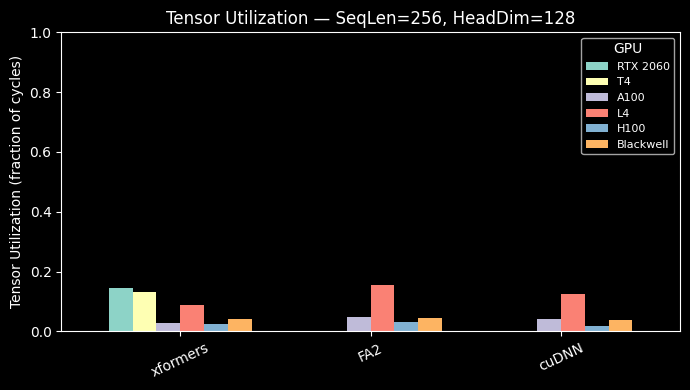

In [23]:
# Example
plot_util_by_gpu_and_kernel(256, 128, 'Tensor_Util', show=True)

In [24]:
for unit_col in UNIT_COLS:
    print(f"Plotting {unit_col}")
    for seq_len in SEQ_LENS:
        print(f"  Seq len {seq_len}")
        for head_dim in HEAD_DIMS:
            print(f"    Head dim {head_dim}")
            plot_util_by_gpu_and_kernel(seq_len, head_dim, unit_col, save=True)

Plotting ALU_Heavy_Util
  Seq len 256
    Head dim 64
    Head dim 128
  Seq len 512
    Head dim 64
    Head dim 128
  Seq len 1024
    Head dim 64
    Head dim 128
  Seq len 2048
    Head dim 64
    Head dim 128
  Seq len 4096
    Head dim 64
    Head dim 128
  Seq len 8192
    Head dim 64
    Head dim 128
Plotting ALU_Util
  Seq len 256
    Head dim 64
    Head dim 128
  Seq len 512
    Head dim 64
    Head dim 128
  Seq len 1024
    Head dim 64
    Head dim 128
  Seq len 2048
    Head dim 64
    Head dim 128
  Seq len 4096
    Head dim 64
    Head dim 128
  Seq len 8192
    Head dim 64
    Head dim 128
Plotting DRAM_Util
  Seq len 256
    Head dim 64
    Head dim 128
  Seq len 512
    Head dim 64
    Head dim 128
  Seq len 1024
    Head dim 64
    Head dim 128
  Seq len 2048
    Head dim 64
    Head dim 128
  Seq len 4096
    Head dim 64
    Head dim 128
  Seq len 8192
    Head dim 64
    Head dim 128
Plotting FMA_Heavy_Util
  Seq len 256
    Head dim 64
    Head dim 128
  Seq len 

### Plot util of all Function Units for certain GPU, Kernel, Seq Len, Head Dim

In [25]:
import os


def plot_util_all_func_units(gpu_name: str, kernel_name: str, seq_len: int, head_dim: int,
                             show: bool = False, save: bool = False):
    """Bar chart of all util_cols for a single (GPU, kernel, seq_len, head_dim) config."""
    sub = agg_df[
        (agg_df['GpuLabel'] == gpu_name) &
        (agg_df['KernelLabel'] == kernel_name) &
        (agg_df['SeqLen'] == seq_len) &
        (agg_df['HeadDim'] == head_dim)
        ]

    assert not sub.empty, (
        f"No data for gpu_name='{gpu_name}', kernel_name='{kernel_name}', "
        f"seq_len={seq_len}, head_dim={head_dim}"
    )

    values = sub[UNIT_COLS].iloc[0]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(UNIT_LABELS, values)
    ax.set_title(f'Functional Unit Utilization — {gpu_name}, {kernel_name}, SeqLen={seq_len}, HeadDim={head_dim}')
    ax.set_xlabel('Functional Unit')
    ax.set_ylabel('Utilization (fraction of cycles)')
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=30)
    fig.tight_layout()

    if not os.path.exists(f'plots'):
        os.makedirs(f'plots')
    if not os.path.exists(f'plots/util_all_func_units'):
        os.makedirs(f'plots/util_all_func_units')
    if not os.path.exists(f'plots/util_all_func_units/{gpu_name}'):
        os.makedirs(f'plots/util_all_func_units/{gpu_name}')

    if save:
        plt.savefig(f'plots/util_all_func_units/{gpu_name}/{gpu_name}_{kernel_name}_{seq_len}x{head_dim}.png')

    if show:
        plt.show()
    else:
        plt.close()


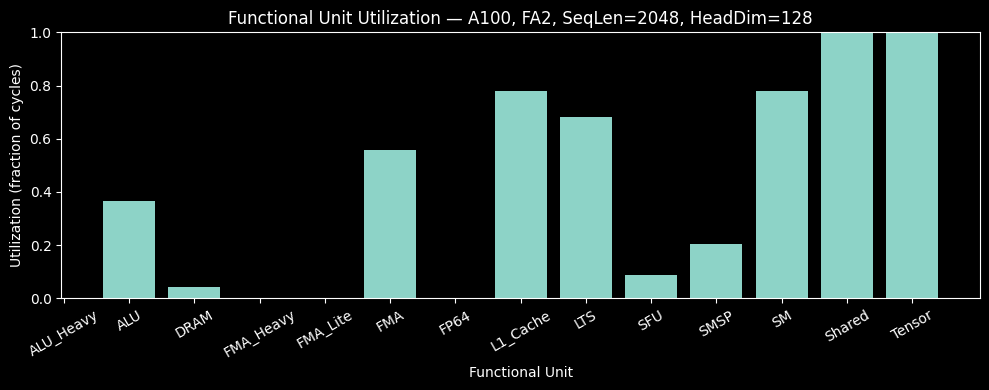

In [26]:
# Example
plot_util_all_func_units('A100', 'FA2', 2048, 128, show=True)

In [27]:
for gpu_name in GPU_ORDER:
    print(f"Plotting {gpu_name}")
    for kernel_name in KERNEL_ORDER:
        print(f"  Kernel {kernel_name}")
        for seq_len in SEQ_LENS:
            print(f"    Seq len {seq_len}")
            for head_dim in HEAD_DIMS:
                print(f"      Head dim {head_dim}")
                try:
                    plot_util_all_func_units(gpu_name, kernel_name, seq_len, head_dim, save=True)
                except AssertionError as e:
                    print(f'      {e}')

Plotting RTX 2060
  Kernel xformers
    Seq len 256
      Head dim 64
      Head dim 128
    Seq len 512
      Head dim 64
      Head dim 128
    Seq len 1024
      Head dim 64
      Head dim 128
    Seq len 2048
      Head dim 64
      Head dim 128
    Seq len 4096
      Head dim 64
      Head dim 128
    Seq len 8192
      Head dim 64
      Head dim 128
  Kernel FA2
    Seq len 256
      Head dim 64
      No data for gpu_name='RTX 2060', kernel_name='FA2', seq_len=256, head_dim=64
      Head dim 128
      No data for gpu_name='RTX 2060', kernel_name='FA2', seq_len=256, head_dim=128
    Seq len 512
      Head dim 64
      No data for gpu_name='RTX 2060', kernel_name='FA2', seq_len=512, head_dim=64
      Head dim 128
      No data for gpu_name='RTX 2060', kernel_name='FA2', seq_len=512, head_dim=128
    Seq len 1024
      Head dim 64
      No data for gpu_name='RTX 2060', kernel_name='FA2', seq_len=1024, head_dim=64
      Head dim 128
      No data for gpu_name='RTX 2060', kernel_name=